In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Titanic.csv')

##Histograms / KDE
Age spikes around 28-30 because of median imputation from phase 1. Fare and fare_per_person are both heavily right-skewed — most passengers paid very little and a few paid a lot.

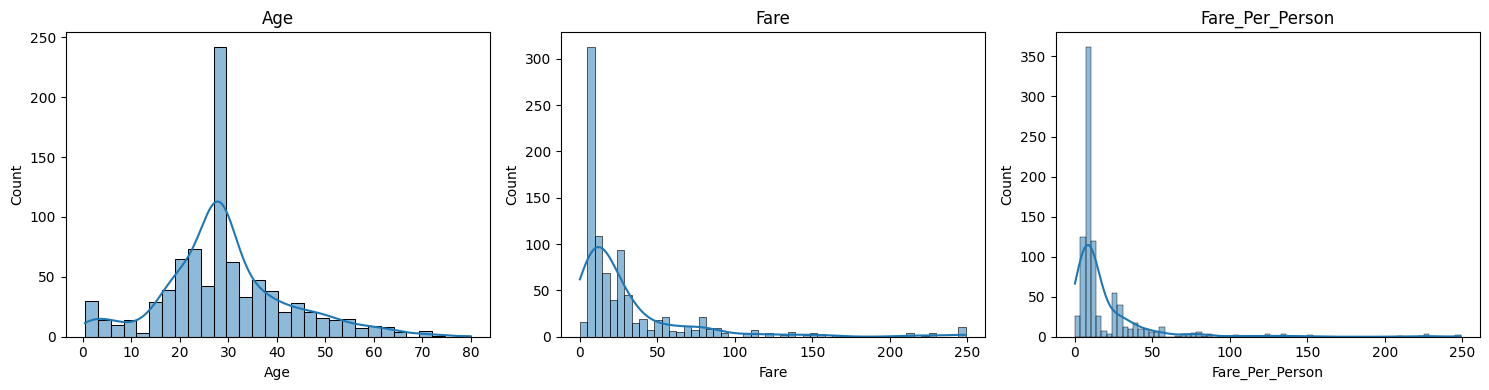

In [3]:
# histogram and kde plots for 3 numeric features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Fare', 'Fare_Per_Person']):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
# After analyzing the charts, the Age chart looks symmetric. On the other hand, the other two are highly right skewed.

##Grouped Boxplots
First plot: 1st class paid significantly more than 2nd and 3rd class.
Second plot: survivors and non-survivors had similar ages overall, confirming age wasn't a strong survival predictor.

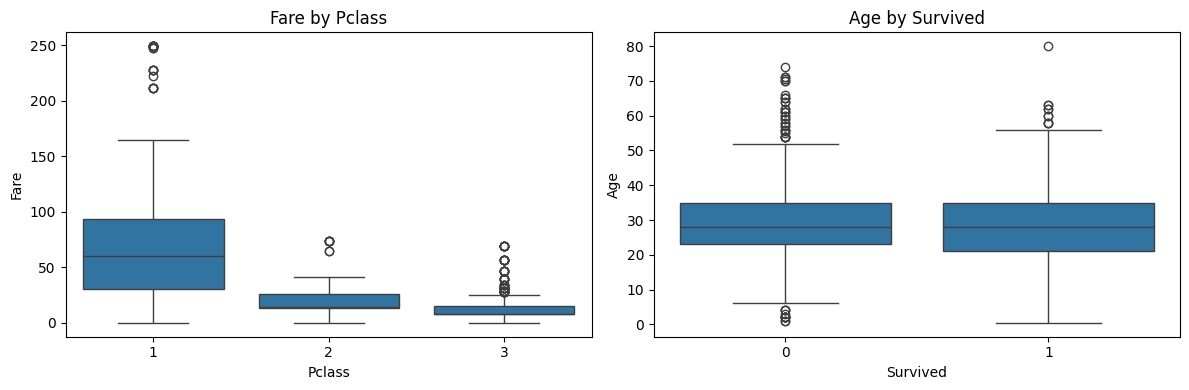

In [4]:
# fare distribution by class and survival
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='Pclass', y='Fare', data=df, ax=axes[0])
axes[0].set_title('Fare by Pclass')
sns.boxplot(x='Survived', y='Age', data=df, ax=axes[1])
axes[1].set_title('Age by Survived')
plt.tight_layout()
plt.show()

##Correlation Heatmap
class_rank and Fare_log are the strongest predictors of survival. is_alone is slightly negative. Age barely correlates at -0.06 so it doesn't tell us much on its own.

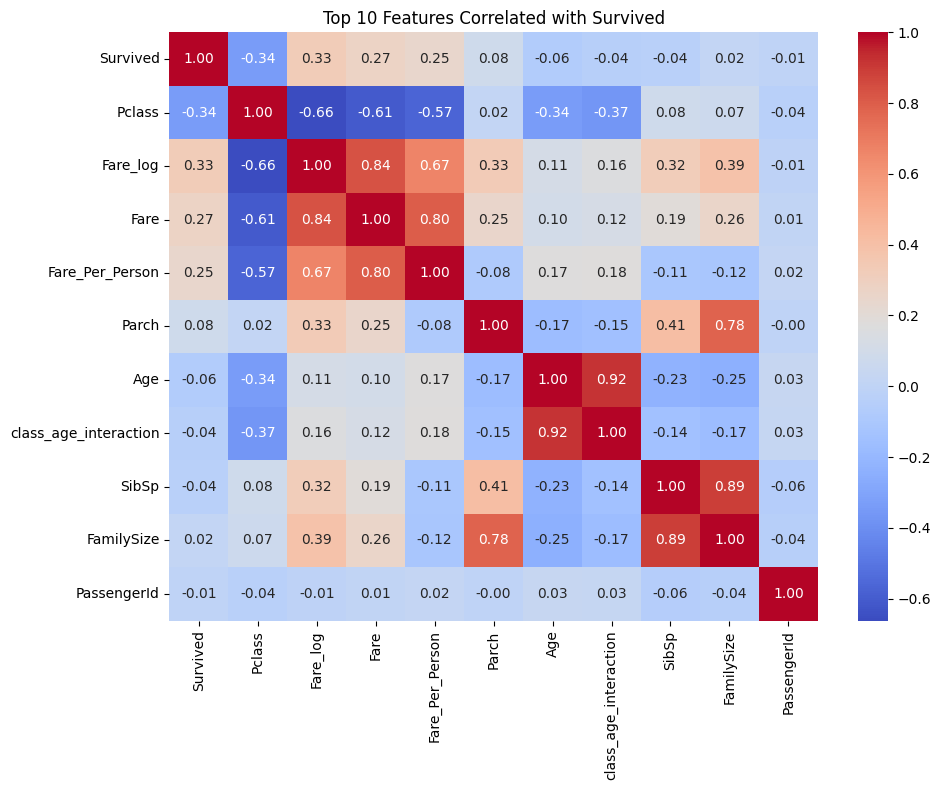

In [5]:
# top 10 features correlated with Survived - Slide 172
numeric_df = df.select_dtypes(include=[np.number])
top10 = numeric_df.corr()['Survived'].abs().nlargest(11).index
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df[top10].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Top 10 Features Correlated with Survived')
plt.tight_layout()
plt.show()

##Scatter Plot
Nearly all of the high-fare passengers at the top of the chart are survivors. Both are mixed together at the bottom, but the overall color is more blue. There is no clear distinction between survivors and non-survivors based on age.

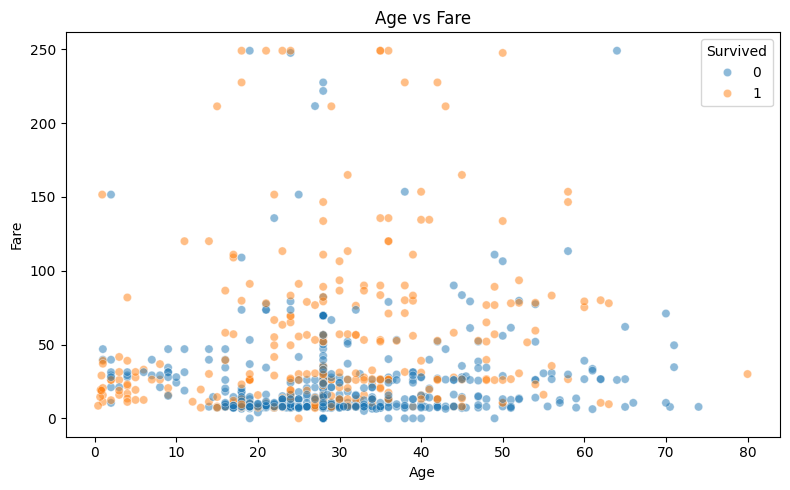

In [6]:
# Age vs Fare coloured by survival
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df, alpha=0.5)
plt.title('Age vs Fare')
plt.tight_layout()
plt.show()


##Groupby Summary
After examining the output, it is noticeable that the 'Child' category has the highest chance of survival (58%), confirming the "women and children first" policy. The lowest is the 'Senior' category (27%), likely due to mobility challenges during evacuation. Adults fall in between at a percentage of (36.5%).

In [7]:
# mean survival rate by age group
print(df.groupby('age_group')['Survived'].mean())

age_group
Adult     0.364362
Child     0.579710
Senior    0.269231
Teen      0.477273
Name: Survived, dtype: float64


### The Math Section

In [8]:
# compute mean and std of Survived using numpy manually. Slide Number 308
target = df['Survived'].to_numpy()
mean = np.sum(target) / len(target)
std  = np.sqrt(np.sum((target - mean) ** 2) / len(target))
print('mean:', round(mean,4))
print('std: ', round(std,4))

mean: 0.3838
std:  0.4863


In [9]:
# standardise Age by hand then compare to StandardScaler. Slide Number 123
age = df['Age'].to_numpy()
z_manual = (age - age.mean()) / age.std()
z_sklearn = StandardScaler().fit_transform(age.reshape(-1, 1)).flatten()
print('max diff:', np.max(np.abs(z_manual - z_sklearn)).round(6))

max diff: 0.0


In [10]:
# cosine similarity between highest and lowest fare passengers. Slide Number 268
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['Survived']).fillna(0)
high = numeric_cols.loc[df['Fare'].idxmax()].to_numpy().astype(float)
low  = numeric_cols.loc[df['Fare'].idxmin()].to_numpy().astype(float)

cos_sim = np.dot(high, low) / (np.linalg.norm(high) * np.linalg.norm(low))
print('cosine similarity:', round(cos_sim, 4))

cosine similarity: 0.1225


In [11]:
# threshold probability with high fare tickets (fare > 100)
high_fare = df[df['Fare'] > 100]
prob_high_fare = np.mean(high_fare['Survived'] == 1)
print(f"P(survived | fare > 100): {prob_high_fare:.4f}")

P(survived | fare > 100): 0.7358
